# A/B Testing Foundations for Content Safety Experimentation

This notebook walks through the statistical foundations of A/B testing in the context of **content safety** at a TikTok-like short-video platform. We cover hypothesis testing, power analysis, multiple testing corrections, CUPED variance reduction, sequential testing, and conclude with a full end-to-end case study.

**Key question**: When we ship a new safety intervention (e.g., AI content labels, friction warnings), how do we measure its causal effect on trust, engagement, and violation rates -- while controlling for false discoveries and minimizing experiment duration?

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

from data.generators.policy_experiments import (
    generate_ab_test_data,
    generate_friction_warning_test,
    generate_sequential_test_data,
    generate_multivariate_test,
)
from utils.statistical_tests import (
    two_sample_z_test,
    two_sample_t_test,
    proportion_z_test,
    sample_size_proportion,
    sample_size_continuous,
    cuped_adjustment,
    sequential_test,
    multiple_testing_correction,
)
from utils.visualization import (
    set_style,
    plot_ab_test_results,
    plot_sequential_test,
    COLORS,
)

%matplotlib inline
set_style()
rng = np.random.default_rng(42)
print("Imports loaded. Ready to go.")

Imports loaded. Ready to go.


---
## Block 1: Statistical Foundations

Every content-safety experiment starts with a **null hypothesis** $H_0$ and an **alternative** $H_1$:

| Component | Definition | Safety Example |
|-----------|-----------|----------------|
| $H_0$ | No treatment effect | AI labels do not change user trust |
| $H_1$ | Treatment has an effect | AI labels increase trust score |
| $\alpha$ (Type I error) | Prob. of rejecting $H_0$ when it is true | Shipping a feature that has no real benefit |
| $\beta$ (Type II error) | Prob. of failing to reject $H_0$ when $H_1$ is true | Missing a real improvement in trust |
| p-value | Prob. of observing data as extreme under $H_0$ | Used to decide whether to ship |
| Confidence interval | Range of plausible effect sizes | Used to assess practical significance |

In safety contexts, **Type II errors can be costly**: failing to detect that a safety intervention works means users remain exposed to harmful content. Conversely, a **Type I error** wastes engineering effort on an ineffective feature.

### Z-test vs T-test

- **Z-test**: Known variance or large samples ($n > 30$). Standard for most platform A/B tests where $n > 10{,}000$.
- **T-test (Welch's)**: Unknown variance, smaller samples, unequal variances. More conservative.

Below we simulate data from two populations, compare both tests, and show the sampling distribution under $H_0$.

=== Z-test ===
  Z-stat: 17.5183, p=0.000000, effect=0.0529
  95% CI: [0.0470, 0.0588], Cohen's d: 0.3504

=== Welch's T-test ===
  t-stat: -17.5183, p=0.000000, effect=0.0529
  95% CI: [0.0470, 0.0588]

True effect: 0.05. Both agree at p<0.05: True


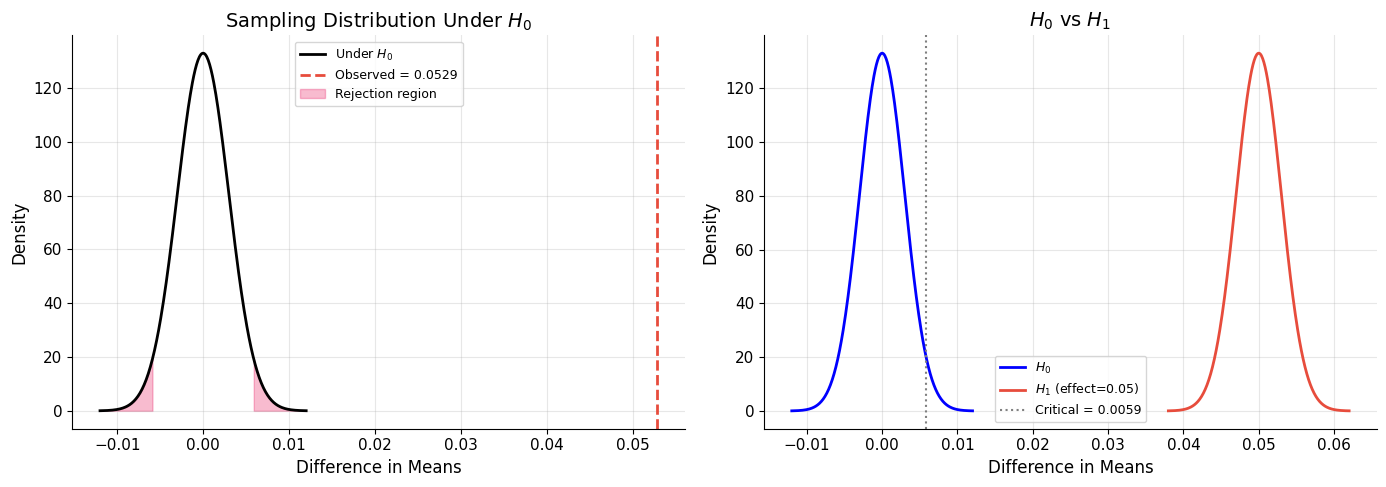

In [2]:
# Demonstrate z-test vs t-test on simulated data with known effect, and show sampling distributions
n = 5000
true_effect = 0.05
control_sim = rng.normal(loc=0.60, scale=0.15, size=n)
treatment_sim = rng.normal(loc=0.60 + true_effect, scale=0.15, size=n)

z_result = two_sample_z_test(control_sim, treatment_sim)
t_result = two_sample_t_test(control_sim, treatment_sim)

print("=== Z-test ===")
print(f"  Z-stat: {z_result['z_stat']:.4f}, p={z_result['p_value']:.6f}, effect={z_result['effect_size']:.4f}")
print(f"  95% CI: [{z_result['ci_lower']:.4f}, {z_result['ci_upper']:.4f}], Cohen's d: {z_result['cohens_d']:.4f}")
print("\n=== Welch's T-test ===")
print(f"  t-stat: {t_result['t_stat']:.4f}, p={t_result['p_value']:.6f}, effect={t_result['effect_size']:.4f}")
print(f"  95% CI: [{t_result['ci_lower']:.4f}, {t_result['ci_upper']:.4f}]")
print(f"\nTrue effect: {true_effect}. Both agree at p<0.05: {z_result['p_value'] < 0.05 and t_result['p_value'] < 0.05}")

# Sampling distribution under H0 and H1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
se = np.sqrt(0.15**2 / n + 0.15**2 / n)
x_range = np.linspace(-4 * se, 4 * se, 300)

axes[0].plot(x_range, stats.norm.pdf(x_range, 0, se), 'k-', lw=2, label='Under $H_0$')
axes[0].axvline(z_result['effect_size'], color=COLORS['treatment'], ls='--', lw=2,
               label=f'Observed = {z_result["effect_size"]:.4f}')
axes[0].fill_between(x_range[x_range >= 1.96*se], stats.norm.pdf(x_range[x_range >= 1.96*se], 0, se),
                    alpha=0.3, color=COLORS['danger'], label='Rejection region')
axes[0].fill_between(x_range[x_range <= -1.96*se], stats.norm.pdf(x_range[x_range <= -1.96*se], 0, se),
                    alpha=0.3, color=COLORS['danger'])
axes[0].set_xlabel('Difference in Means'); axes[0].set_ylabel('Density')
axes[0].set_title('Sampling Distribution Under $H_0$'); axes[0].legend(fontsize=9)

axes[1].plot(x_range, stats.norm.pdf(x_range, 0, se), 'b-', lw=2, label='$H_0$')
x_h1 = np.linspace(true_effect - 4*se, true_effect + 4*se, 300)
axes[1].plot(x_h1, stats.norm.pdf(x_h1, true_effect, se), color=COLORS['treatment'], lw=2,
            label=f'$H_1$ (effect={true_effect})')
axes[1].axvline(1.96*se, color='gray', ls=':', label=f'Critical = {1.96*se:.4f}')
axes[1].set_xlabel('Difference in Means'); axes[1].set_ylabel('Density')
axes[1].set_title('$H_0$ vs $H_1$'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### Visualizing Type I and Type II Error Regions

- **Type I (red)**: shaded tails of $H_0$ beyond the critical value, controlled by $\alpha$.
- **Type II (orange)**: area of $H_1$ inside the acceptance region, denoted $\beta$.
- **Power (green)**: $1 - \beta$, the probability of correctly detecting a true effect.

Critical value: +/- 0.0059
Beta (Type II error): 0.0012, Power: 0.9988


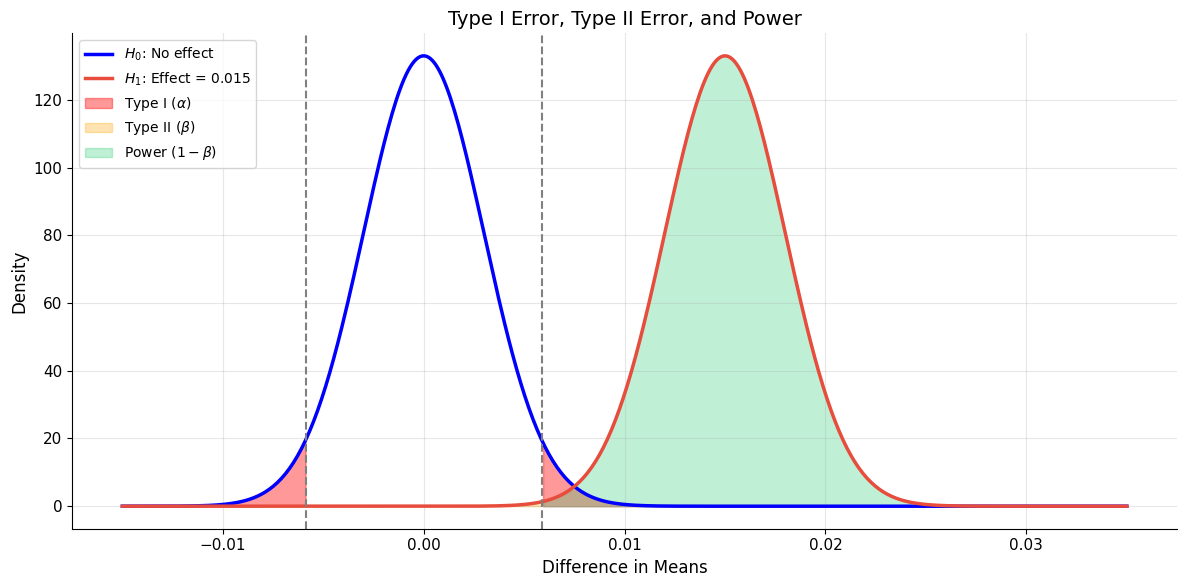

In [3]:
# Visualize Type I and Type II error regions with power
fig, ax = plt.subplots(figsize=(12, 6))
se_viz, effect_viz = 0.003, 0.015
crit = 1.96 * se_viz
x = np.linspace(-0.015, 0.035, 500)

ax.plot(x, stats.norm.pdf(x, 0, se_viz), 'b-', lw=2.5, label='$H_0$: No effect')
ax.plot(x, stats.norm.pdf(x, effect_viz, se_viz), color=COLORS['treatment'], lw=2.5,
       label=f'$H_1$: Effect = {effect_viz}')

# Type I error (alpha)
ax.fill_between(x[x >= crit], stats.norm.pdf(x[x >= crit], 0, se_viz), alpha=0.4, color='red',
               label='Type I ($\\alpha$)')
ax.fill_between(x[x <= -crit], stats.norm.pdf(x[x <= -crit], 0, se_viz), alpha=0.4, color='red')
# Type II error (beta)
x_t2 = x[(x >= -crit) & (x <= crit)]
ax.fill_between(x_t2, stats.norm.pdf(x_t2, effect_viz, se_viz), alpha=0.3, color='orange',
               label='Type II ($\\beta$)')
# Power
ax.fill_between(x[x >= crit], stats.norm.pdf(x[x >= crit], effect_viz, se_viz), alpha=0.3,
               color=COLORS['accent'], label='Power ($1-\\beta$)')

ax.axvline(crit, color='gray', ls='--', lw=1.5); ax.axvline(-crit, color='gray', ls='--', lw=1.5)
ax.set_xlabel('Difference in Means'); ax.set_ylabel('Density')
ax.set_title('Type I Error, Type II Error, and Power'); ax.legend(loc='upper left', fontsize=10)

beta = stats.norm.cdf(crit, effect_viz, se_viz) - stats.norm.cdf(-crit, effect_viz, se_viz)
print(f"Critical value: +/- {crit:.4f}")
print(f"Beta (Type II error): {beta:.4f}, Power: {1-beta:.4f}")
plt.tight_layout(); plt.show()

---
## Block 2: Core A/B Testing Workflow

A standard A/B test at a platform like TikTok follows this workflow:

1. **Hypothesis**: "AI content labels increase user trust without catastrophic engagement loss."
2. **Primary metric**: `post_trust_score` (continuous, 0-1)
3. **Guardrail metric**: `post_engagement_rate` (must not drop > 5% relatively)
4. **Design**: 50/50 split, sample size from power analysis
5. **Run**: Collect data for pre-determined duration
6. **Analyze**: Two-sample test, compute CIs, check guardrails

We load the synthetic AI Content Label dataset: 10,000 users split 50/50. Treatment users see explicit "AI-generated" labels on synthetic content.

In [4]:
# Load AB test data from the policy_experiments generator
df_ab = generate_ab_test_data(n_users=10_000, effect_size=0.05, seed=42)
print(f"Shape: {df_ab.shape}, Columns: {list(df_ab.columns)}")
print(f"\nGroup split:\n{df_ab['group'].value_counts()}")
df_ab.head()

Shape: (10000, 17), Columns: ['user_id', 'group', 'pre_engagement_rate', 'post_engagement_rate', 'pre_trust_score', 'post_trust_score', 'sessions', 'time_spent_minutes', 'content_created', 'content_shared', 'violations_reported', 'violations_confirmed', 'ai_content_interacted', 'region', 'platform', 'account_age_days', 'is_creator']

Group split:
group
treatment    5000
control      5000
Name: count, dtype: int64


,user_id,group,pre_engagement_rate,post_engagement_rate,pre_trust_score,post_trust_score,sessions,time_spent_minutes,content_created,content_shared,violations_reported,violations_confirmed,ai_content_interacted,region,platform,account_age_days,is_creator
0,1,treatment,0.2674,0.2833,0.7275,0.7766,13,27.1,1,2,1,1,3,LATAM,android,1154,False
1,2,treatment,0.4689,0.4482,0.6094,0.6906,16,16.0,0,4,0,0,2,NA,web,739,False
2,3,control,0.0463,0.0478,0.8652,0.8224,19,15.5,0,4,1,0,0,SEA,android,1189,False
3,4,treatment,0.2834,0.2658,0.9088,0.9952,11,17.5,0,2,0,0,5,SEA,ios,287,False
4,5,control,0.5081,0.5380,0.6969,0.6918,12,15.6,0,3,1,1,0,EMEA,ios,92,False


### Primary and Guardrail Metrics

We run a two-sample z-test on trust score (primary) and engagement rate (guardrail). The engagement guardrail requires no more than 5% relative decline.

In [5]:
# Compare control vs treatment on trust_score and engagement_rate
ctrl_trust = df_ab.loc[df_ab['group'] == 'control', 'post_trust_score'].values
treat_trust = df_ab.loc[df_ab['group'] == 'treatment', 'post_trust_score'].values
trust_result = two_sample_z_test(ctrl_trust, treat_trust)

ctrl_eng = df_ab.loc[df_ab['group'] == 'control', 'post_engagement_rate'].values
treat_eng = df_ab.loc[df_ab['group'] == 'treatment', 'post_engagement_rate'].values
eng_result = two_sample_z_test(ctrl_eng, treat_eng)

print("=== Trust Score ===")
print(f"  Control: {trust_result['control_mean']:.4f}, Treatment: {trust_result['treatment_mean']:.4f}")
print(f"  Effect: {trust_result['effect_size']:+.4f}, Z={trust_result['z_stat']:.3f}, p={trust_result['p_value']:.2e}")
print(f"  95% CI: [{trust_result['ci_lower']:.4f}, {trust_result['ci_upper']:.4f}], d={trust_result['cohens_d']:.4f}")
print(f"  -> {'SIGNIFICANT' if trust_result['p_value'] < 0.05 else 'Not significant'}")

print("\n=== Engagement Rate ===")
print(f"  Control: {eng_result['control_mean']:.4f}, Treatment: {eng_result['treatment_mean']:.4f}")
print(f"  Effect: {eng_result['effect_size']:+.4f}, Z={eng_result['z_stat']:.3f}, p={eng_result['p_value']:.2e}")
print(f"  95% CI: [{eng_result['ci_lower']:.4f}, {eng_result['ci_upper']:.4f}]")
rel_drop = eng_result['effect_size'] / eng_result['control_mean'] * 100
print(f"  Relative change: {rel_drop:+.2f}%, Guardrail: {'PASS' if abs(rel_drop) < 5 else 'FAIL'}")

=== Trust Score ===
  Control: 0.6216, Treatment: 0.6871
  Effect: +0.0655, Z=19.726, p=0.00e+00
  95% CI: [0.0590, 0.0720], d=0.3945
  -> SIGNIFICANT

=== Engagement Rate ===
  Control: 0.2851, Treatment: 0.2614
  Effect: -0.0237, Z=-7.291, p=3.08e-13
  95% CI: [-0.0301, -0.0173]
  Relative change: -8.32%, Guardrail: FAIL


### Visualize Results and Compute Practical Significance

We plot distributions with `plot_ab_test_results` and compute relative lifts across all key metrics to assess practical significance.

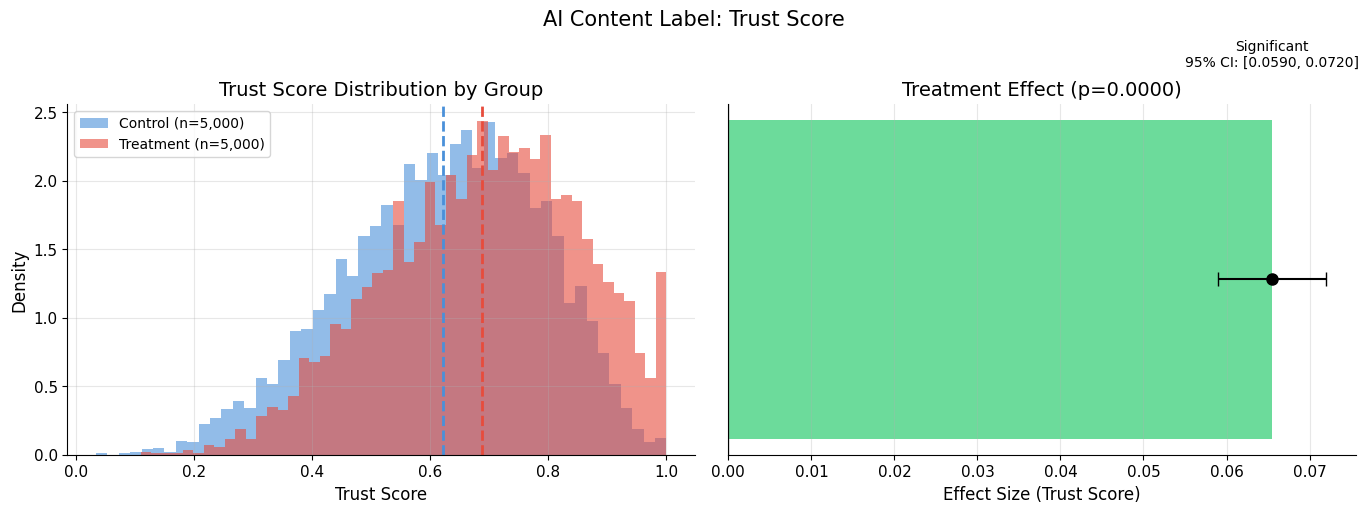

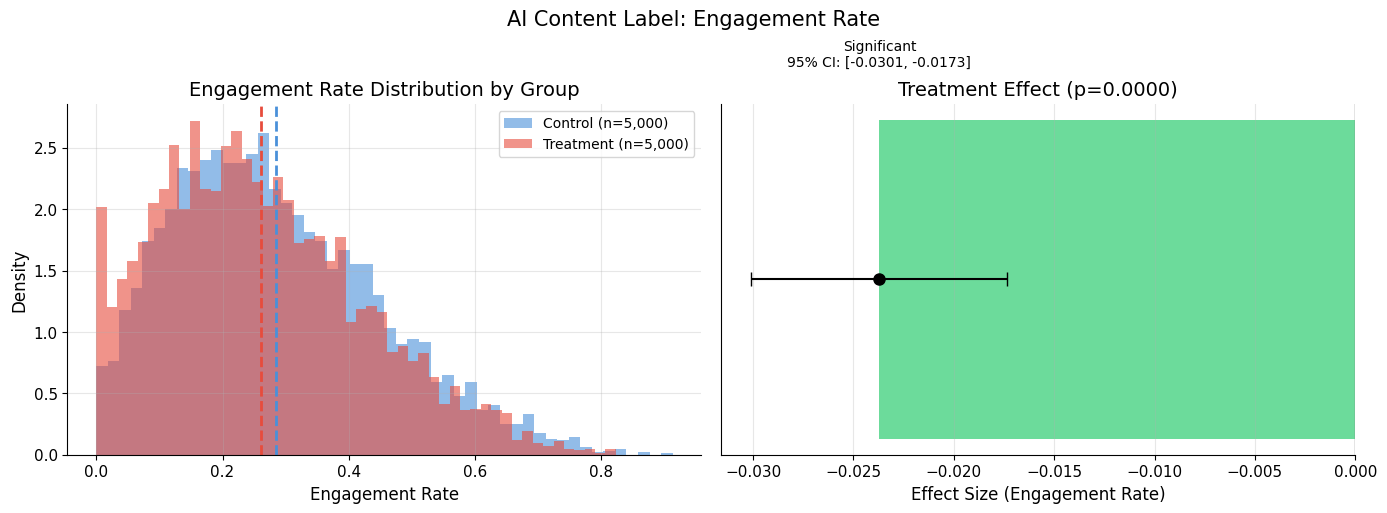

In [6]:
# Visualize AB test results for trust and engagement
fig = plot_ab_test_results(ctrl_trust, treat_trust, metric_name='Trust Score', test_result=trust_result)
plt.suptitle('AI Content Label: Trust Score', fontsize=15, y=1.02); plt.show()

fig = plot_ab_test_results(ctrl_eng, treat_eng, metric_name='Engagement Rate', test_result=eng_result)
plt.suptitle('AI Content Label: Engagement Rate', fontsize=15, y=1.02); plt.show()

In [7]:
# Compute relative lift and practical significance for all key metrics
lift_metrics = {
    'trust_score': 'post_trust_score', 'engagement_rate': 'post_engagement_rate',
    'violations_reported': 'violations_reported', 'content_shared': 'content_shared',
    'time_spent_minutes': 'time_spent_minutes',
}
print("=" * 80)
print(f"{'Metric':<25} {'Control':>10} {'Treatment':>10} {'Lift':>10} {'Rel %':>8} {'p':>10}")
print("=" * 80)
for name, col in lift_metrics.items():
    r = two_sample_z_test(df_ab.loc[df_ab['group']=='control', col].values,
                          df_ab.loc[df_ab['group']=='treatment', col].values)
    rl = r['effect_size'] / r['control_mean'] * 100 if r['control_mean'] else 0
    sig = '***' if r['p_value']<0.001 else '**' if r['p_value']<0.01 else '*' if r['p_value']<0.05 else ''
    print(f"{name:<25} {r['control_mean']:>10.4f} {r['treatment_mean']:>10.4f} "
          f"{r['effect_size']:>+10.4f} {rl:>+7.2f}% {r['p_value']:>10.4f} {sig}")
print("=" * 80)
print("*** p<0.001  ** p<0.01  * p<0.05")

Metric                       Control  Treatment       Lift    Rel %          p
trust_score                   0.6216     0.6871    +0.0655  +10.53%     0.0000 ***
engagement_rate               0.2851     0.2614    -0.0237   -8.32%     0.0000 ***


violations_reported           0.2490     0.2644    +0.0154   +6.18%     0.1390 
content_shared                2.0108     1.9782    -0.0326   -1.62%     0.2457 
time_spent_minutes           24.0184    23.6607    -0.3578   -1.49%     0.1886 
*** p<0.001  ** p<0.01  * p<0.05


---
## Block 3: Sample Size & Power Analysis

Statistical power depends on four quantities -- fix any three to solve for the fourth:

- $\alpha$ (significance level, typically 0.05)
- Power $= 1 - \beta$ (usually 0.80)
- MDE (minimum detectable effect)
- $n$ (sample size per group)

We compute required samples for both proportion and continuous metrics, then plot power curves and the MDE-vs-sample-size tradeoff.

In [8]:
# Required sample sizes for typical safety metrics
print("=== Sample Sizes (per group, alpha=0.05, power=0.80) ===\n")
print("--- Proportions ---")
for name, bl, mde in [('Violation rate', .03, .005), ('Violation rate', .03, .01),
                       ('7d churn', .08, .01), ('7d churn', .08, .02), ('Flag rate', .15, .02)]:
    print(f"  {name} (base={bl:.1%}, MDE={mde:.1%}): n = {sample_size_proportion(bl, mde):>8,}")
print("\n--- Continuous ---")
for name, s, mde in [('Trust', .18, .02), ('Trust', .18, .05), ('Engagement', .15, .01),
                      ('Engagement', .15, .02), ('Time (min)', 25., 2.)]:
    print(f"  {name} (std={s}, MDE={mde}): n = {sample_size_continuous(s, mde):>8,}")

=== Sample Sizes (per group, alpha=0.05, power=0.80) ===

--- Proportions ---
  Violation rate (base=3.0%, MDE=0.5%): n =   18,708
  Violation rate (base=3.0%, MDE=1.0%): n =    4,782
  7d churn (base=8.0%, MDE=1.0%): n =   11,748
  7d churn (base=8.0%, MDE=2.0%): n =    2,984
  Flag rate (base=15.0%, MDE=2.0%): n =    5,084

--- Continuous ---
  Trust (std=0.18, MDE=0.02): n =    1,272
  Trust (std=0.18, MDE=0.05): n =      204
  Engagement (std=0.15, MDE=0.01): n =    3,532
  Engagement (std=0.15, MDE=0.02): n =      883
  Time (min) (std=25.0, MDE=2.0): n =    2,453


### Power Curves and MDE Tradeoff

Power curves show how detection capability scales with $n$. The MDE tradeoff plot reveals the fundamental law: halving the MDE quadruples the sample requirement.

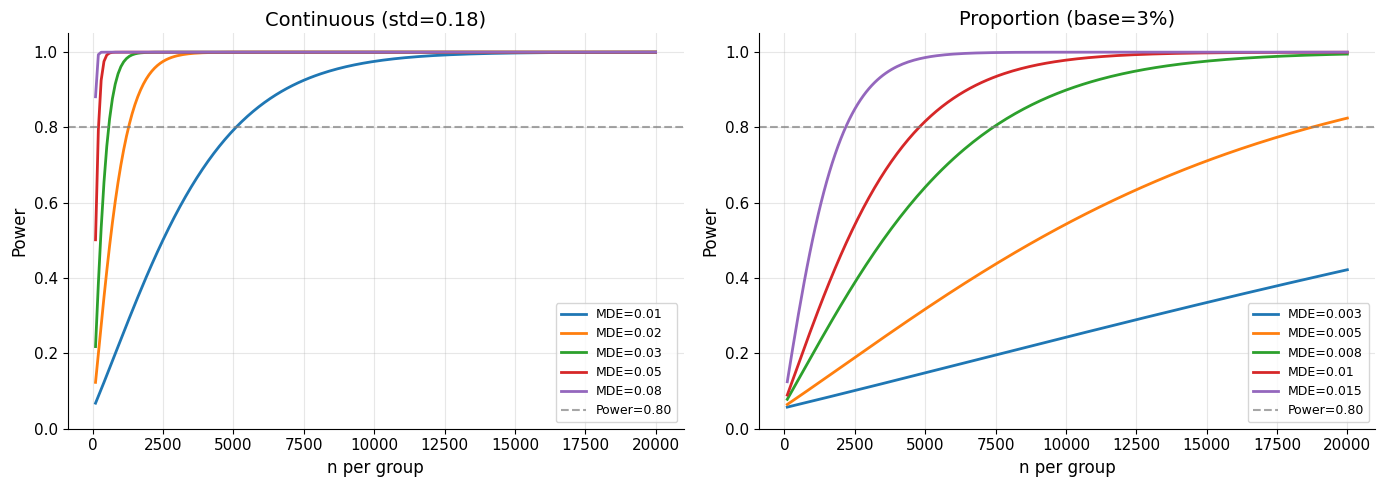

In [9]:
# Plot power curves for continuous and proportion metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_range = np.arange(100, 20001, 100)
z_a = stats.norm.ppf(0.975)
colors5 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for es, c in zip([.01,.02,.03,.05,.08], colors5):
    se_a = 0.18 * np.sqrt(2 / n_range)
    pw = 1 - stats.norm.cdf(z_a - es/se_a) + stats.norm.cdf(-z_a - es/se_a)
    axes[0].plot(n_range, pw, '-', color=c, lw=2, label=f'MDE={es}')
axes[0].axhline(.8, color='gray', ls='--', alpha=.7, label='Power=0.80')
axes[0].set(xlabel='n per group', ylabel='Power', title='Continuous (std=0.18)', ylim=(0,1.05))
axes[0].legend(fontsize=9)

bp = 0.03
for mde, c in zip([.003,.005,.008,.01,.015], colors5):
    p2 = bp + mde
    se_a = np.sqrt(bp*(1-bp)/n_range + p2*(1-p2)/n_range)
    se_h0 = np.sqrt(2*bp*(1-bp)/n_range)
    pw = 1 - stats.norm.cdf((z_a*se_h0-mde)/se_a) + stats.norm.cdf((-z_a*se_h0-mde)/se_a)
    axes[1].plot(n_range, pw, '-', color=c, lw=2, label=f'MDE={mde}')
axes[1].axhline(.8, color='gray', ls='--', alpha=.7, label='Power=0.80')
axes[1].set(xlabel='n per group', ylabel='Power', title='Proportion (base=3%)', ylim=(0,1.05))
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

Trust score (MDE=0.03): n = 566 per group

         Daily Users      Per Arm     Days    Weeks
               1,000          500        2      0.3
               5,000        2,500        1      0.1
              10,000        5,000        1      0.1
              50,000       25,000        1      0.1
             100,000       50,000        1      0.1
             500,000      250,000        1      0.1


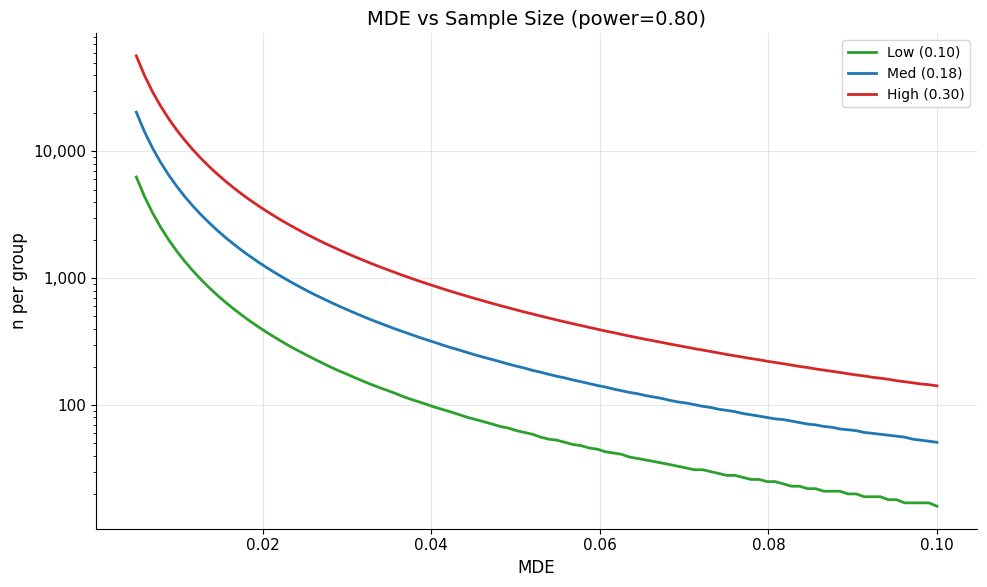


Halving MDE: n(0.05)=204 vs n(0.025)=814


In [10]:
# Experiment duration and MDE-vs-sample-size tradeoff
n_req = sample_size_continuous(0.18, 0.03)
print(f"Trust score (MDE=0.03): n = {n_req:,} per group\n")
print(f"{'Daily Users':>20} {'Per Arm':>12} {'Days':>8} {'Weeks':>8}")
for d in [1000, 5000, 10000, 50000, 100000, 500000]:
    pa = d // 2; days = int(np.ceil(n_req / pa))
    print(f"{d:>20,} {pa:>12,} {days:>8} {days/7:>8.1f}")

# MDE vs n plot
fig, ax = plt.subplots(figsize=(10, 6))
mde_r = np.linspace(0.005, 0.10, 100)
for sv, lb, co in [(.10,'Low (0.10)','#2ca02c'), (.18,'Med (0.18)','#1f77b4'), (.30,'High (0.30)','#d62728')]:
    ax.plot(mde_r, [sample_size_continuous(sv, m) for m in mde_r], '-', color=co, lw=2, label=lb)
ax.set(xlabel='MDE', ylabel='n per group', title='MDE vs Sample Size (power=0.80)')
ax.set_yscale('log'); ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(); plt.tight_layout(); plt.show()
print(f"\nHalving MDE: n({.05})={sample_size_continuous(.18,.05):,} vs n({.025})={sample_size_continuous(.18,.025):,}")

---
## Block 4: Multiple Testing Corrections

A typical safety experiment tests many metrics simultaneously. With $m$ tests at $\alpha=0.05$, the family-wise false positive probability reaches $1-(1-\alpha)^m$. With 10 metrics, that is 40%.

- **FWER** (Bonferroni, Holm): Controls probability of *any* false positive. Use for primary/guardrail metrics.
- **FDR** (Benjamini-Hochberg): Controls the *proportion* of false positives. Use for exploratory analyses.

We demonstrate on the friction warning experiment, which measures violations, satisfaction, churn, and posting behavior.

In [11]:
# Multiple metrics from friction_warning test
df_fw = generate_friction_warning_test(n_users=8_000, seed=42)
ctrl_fw, treat_fw = df_fw[df_fw['group']=='control'], df_fw[df_fw['group']=='treatment']
print(f"Friction warning: {len(df_fw):,} users, {df_fw['group'].value_counts().to_dict()}\n")

p_values, metric_names = [], []
for col, lbl in [('violations_confirmed','Confirmed Violations'), ('violations_flagged','Flagged Violations'),
                  ('user_satisfaction_score','Satisfaction'), ('posts_completed','Posts Completed')]:
    r = two_sample_z_test(ctrl_fw[col].values, treat_fw[col].values)
    p_values.append(r['p_value']); metric_names.append(lbl)
for cc, lbl in [('churn_7d','7-Day Churn'), ('churn_30d','30-Day Churn')]:
    r = proportion_z_test(int(ctrl_fw[cc].sum()), len(ctrl_fw), int(treat_fw[cc].sum()), len(treat_fw))
    p_values.append(r['p_value']); metric_names.append(lbl)
p_values = np.array(p_values)

print(f"{'Metric':<25} {'p-value':>10} {'Sig?':>6}")
print("-" * 45)
for nm, pv in zip(metric_names, p_values):
    print(f"{nm:<25} {pv:>10.6f} {'Yes' if pv<0.05 else 'No':>6}")
print(f"\nRejections (raw): {(p_values<0.05).sum()}/{len(p_values)}")

Friction warning: 8,000 users, {'treatment': 4000, 'control': 4000}

Metric                       p-value   Sig?
---------------------------------------------
Confirmed Violations        0.000000    Yes
Flagged Violations          0.000000    Yes
Satisfaction                0.000000    Yes
Posts Completed             0.000000    Yes
7-Day Churn                 0.000000    Yes
30-Day Churn                0.000000    Yes

Rejections (raw): 6/6


In [12]:
# Apply Bonferroni, Holm, BH corrections and show how conclusions change
bonf = multiple_testing_correction(p_values, method='bonferroni')
holm = multiple_testing_correction(p_values, method='holm')
bh = multiple_testing_correction(p_values, method='bh')

print(f"{'Metric':<25} {'Raw':>10} {'Bonf':>10} {'Holm':>10} {'BH':>10}")
print("=" * 70)
for i, nm in enumerate(metric_names):
    print(f"{nm:<25} {p_values[i]:>10.6f} {bonf['adjusted_p_values'][i]:>10.6f} "
          f"{holm['adjusted_p_values'][i]:>10.6f} {bh['adjusted_p_values'][i]:>10.6f}")
print(f"\nRejections: Raw={int((p_values<.05).sum())}, Bonf={bonf['n_rejected']}, "
      f"Holm={holm['n_rejected']}, BH={bh['n_rejected']}")

print("\n--- Impact on conclusions ---")
for i, nm in enumerate(metric_names):
    raw = p_values[i] < 0.05
    if not raw: print(f"  {nm}: not significant even without correction")
    elif bonf['adjusted_p_values'][i] < 0.05: print(f"  {nm}: survives all corrections")
    else:
        lost = [m for m, adj in [('Bonf', bonf), ('Holm', holm), ('BH', bh)] if adj['adjusted_p_values'][i] >= 0.05]
        print(f"  {nm}: lost with {', '.join(lost)}")

Metric                           Raw       Bonf       Holm         BH
Confirmed Violations        0.000000   0.000000   0.000000   0.000000
Flagged Violations          0.000000   0.000000   0.000000   0.000000
Satisfaction                0.000000   0.000000   0.000000   0.000000
Posts Completed             0.000000   0.000000   0.000000   0.000000
7-Day Churn                 0.000000   0.000000   0.000000   0.000000
30-Day Churn                0.000000   0.000000   0.000000   0.000000

Rejections: Raw=6, Bonf=6, Holm=6, BH=6

--- Impact on conclusions ---
  Confirmed Violations: survives all corrections
  Flagged Violations: survives all corrections
  Satisfaction: survives all corrections
  Posts Completed: survives all corrections
  7-Day Churn: survives all corrections
  30-Day Churn: survives all corrections


/var/folders/s0/g7fbgbjs2710z5hy6lcg_xlw0000gn/T/ipykernel_26460/1345283337.py:9: RuntimeWarning: divide by zero encountered in log10
  ax.barh(y + offset, -np.log10(vals), h, color=color, alpha=0.8, label=label)


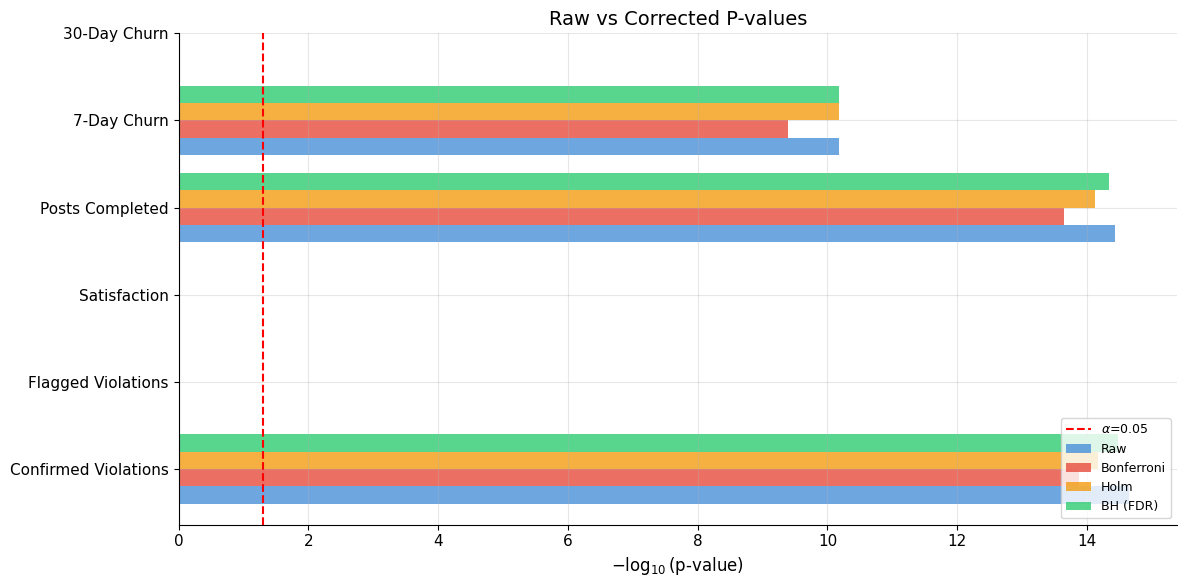

In [13]:
# Visualize adjusted vs unadjusted p-values
fig, ax = plt.subplots(figsize=(12, 6))
y = np.arange(len(metric_names)); h = 0.2
for offset, vals, color, label in [
    (-1.5*h, p_values, COLORS['control'], 'Raw'),
    (-0.5*h, bonf['adjusted_p_values'], COLORS['treatment'], 'Bonferroni'),
    (0.5*h, holm['adjusted_p_values'], COLORS['warning'], 'Holm'),
    (1.5*h, bh['adjusted_p_values'], COLORS['accent'], 'BH (FDR)')]:
    ax.barh(y + offset, -np.log10(vals), h, color=color, alpha=0.8, label=label)
ax.axvline(-np.log10(0.05), color='red', ls='--', lw=1.5, label='$\\alpha$=0.05')
ax.set_yticks(y); ax.set_yticklabels(metric_names)
ax.set_xlabel('$-\\log_{10}$(p-value)'); ax.set_title('Raw vs Corrected P-values')
ax.legend(loc='lower right', fontsize=9); plt.tight_layout(); plt.show()

---
## Block 5: CUPED Variance Reduction

**CUPED** (Controlled-experiment Using Pre-Experiment Data) adjusts the post-experiment metric using a correlated pre-experiment covariate:

$$\hat{Y}_{\text{CUPED}} = Y_{\text{post}} - \theta (X_{\text{pre}} - \bar{X}_{\text{pre}}), \quad \theta = \frac{\text{Cov}(Y, X)}{\text{Var}(X)}$$

This removes variance from pre-existing user differences without biasing the treatment effect. Variance reduction can reach $R^2$, cutting required sample size by 30-60%.

In [14]:
# Apply CUPED to trust and engagement, compare CI widths
group_bin = (df_ab['group'] == 'treatment').astype(int).values
ctrl_mask = df_ab['group'] == 'control'
treat_mask = df_ab['group'] == 'treatment'

trust_adj, trust_vr = cuped_adjustment(df_ab['post_trust_score'].values, df_ab['pre_trust_score'].values, group_bin)
eng_adj, eng_vr = cuped_adjustment(df_ab['post_engagement_rate'].values, df_ab['pre_engagement_rate'].values, group_bin)

trust_cuped_res = two_sample_z_test(trust_adj[ctrl_mask], trust_adj[treat_mask])
eng_cuped_res = two_sample_z_test(eng_adj[ctrl_mask], eng_adj[treat_mask])

print("=== CUPED Results ===")
print(f"\nTrust: var reduction={trust_vr:.1%}")
print(f"  Effect={trust_cuped_res['effect_size']:+.4f}, Z={trust_cuped_res['z_stat']:.3f}, p={trust_cuped_res['p_value']:.2e}")
print(f"  Raw CI width:   {trust_result['ci_upper']-trust_result['ci_lower']:.4f}")
print(f"  CUPED CI width: {trust_cuped_res['ci_upper']-trust_cuped_res['ci_lower']:.4f}")
print(f"\nEngagement: var reduction={eng_vr:.1%}")
print(f"  Raw CI width:   {eng_result['ci_upper']-eng_result['ci_lower']:.4f}")
print(f"  CUPED CI width: {eng_cuped_res['ci_upper']-eng_cuped_res['ci_lower']:.4f}")

=== CUPED Results ===

Trust: var reduction=93.8%
  Effect=+0.0626, Z=111.712, p=0.00e+00
  Raw CI width:   0.0130
  CUPED CI width: 0.0022

Engagement: var reduction=97.6%
  Raw CI width:   0.0127
  CUPED CI width: 0.0017


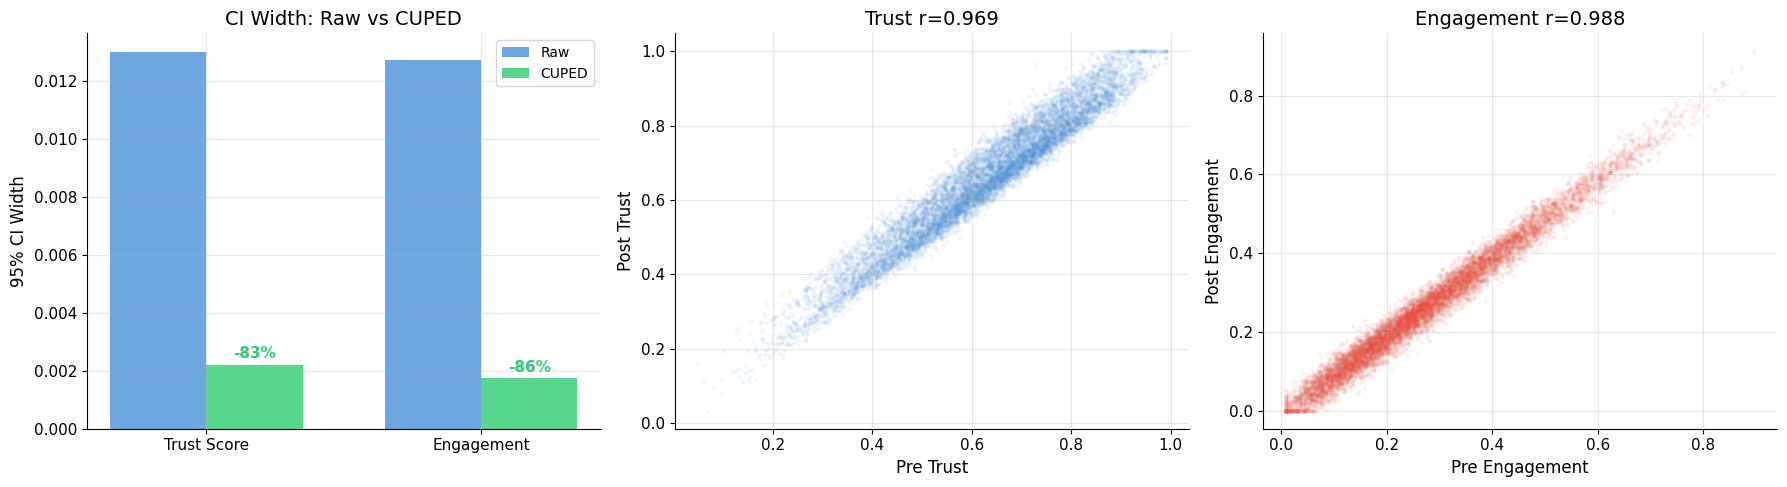

R-squared (theoretical max): Trust=93.8%, Engagement=97.6%
Actual CUPED reduction:       Trust=93.8%, Engagement=97.6%


In [15]:
# Visualize CI width reduction and pre-post correlation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CI width comparison
labels = ['Trust Score', 'Engagement']
raw_w = [trust_result['ci_upper']-trust_result['ci_lower'], eng_result['ci_upper']-eng_result['ci_lower']]
cup_w = [trust_cuped_res['ci_upper']-trust_cuped_res['ci_lower'], eng_cuped_res['ci_upper']-eng_cuped_res['ci_lower']]
x = np.arange(2); w = 0.35
axes[0].bar(x-w/2, raw_w, w, label='Raw', color=COLORS['control'], alpha=.8)
axes[0].bar(x+w/2, cup_w, w, label='CUPED', color=COLORS['accent'], alpha=.8)
for i in range(2):
    axes[0].annotate(f'-{(1-cup_w[i]/raw_w[i])*100:.0f}%', xy=(i+w/2, cup_w[i]),
                    xytext=(0,5), textcoords='offset points', ha='center', fontweight='bold', color=COLORS['accent'])
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('95% CI Width'); axes[0].set_title('CI Width: Raw vs CUPED'); axes[0].legend()

# Pre-post scatter
corr_t = np.corrcoef(df_ab['pre_trust_score'], df_ab['post_trust_score'])[0,1]
axes[1].scatter(df_ab['pre_trust_score'], df_ab['post_trust_score'], alpha=.05, s=5, color=COLORS['control'])
axes[1].set(xlabel='Pre Trust', ylabel='Post Trust', title=f'Trust r={corr_t:.3f}')

corr_e = np.corrcoef(df_ab['pre_engagement_rate'], df_ab['post_engagement_rate'])[0,1]
axes[2].scatter(df_ab['pre_engagement_rate'], df_ab['post_engagement_rate'], alpha=.05, s=5, color=COLORS['treatment'])
axes[2].set(xlabel='Pre Engagement', ylabel='Post Engagement', title=f'Engagement r={corr_e:.3f}')

plt.tight_layout(); plt.show()
print(f"R-squared (theoretical max): Trust={corr_t**2:.1%}, Engagement={corr_e**2:.1%}")
print(f"Actual CUPED reduction:       Trust={trust_vr:.1%}, Engagement={eng_vr:.1%}")

In [16]:
# Demonstrate how CUPED reduces required sample size
std_raw = np.std(df_ab['post_trust_score'], ddof=1)
std_cup = np.std(trust_adj, ddof=1)
n_r = sample_size_continuous(std_raw, 0.03)
n_c = sample_size_continuous(std_cup, 0.03)

print(f"=== Sample Size Savings (Trust, MDE=0.03) ===")
print(f"  Raw std={std_raw:.4f} -> n={n_r:,}")
print(f"  CUPED std={std_cup:.4f} -> n={n_c:,}")
print(f"  Savings: {n_r-n_c:,} users ({(1-n_c/n_r):.0%})")
print(f"\nAt 10k daily users: Raw={int(np.ceil(n_r/5000))}d, CUPED={int(np.ceil(n_c/5000))}d")

=== Sample Size Savings (Trust, MDE=0.03) ===
  Raw std=0.1692 -> n=500
  CUPED std=0.0420 -> n=31
  Savings: 469 users (94%)

At 10k daily users: Raw=1d, CUPED=1d


---
## Block 6: Advanced Topics

### Sequential Testing and Multi-Armed Bandits

| Approach | Pros | Cons | When |
|----------|------|------|------|
| Fixed A/B | Simple, high power | Cannot stop early | Standard launches |
| Sequential | Valid early stopping | Slightly lower power | Safety-critical |
| Thompson sampling | Minimizes regret | Harder inference | Multi-variant |

In [17]:
# Sequential test with O'Brien-Fleming boundaries
df_seq = generate_sequential_test_data(n_users_per_day=500, n_days=30, effect_size=0.03, seed=42)
print(f"Sequential data: {df_seq.shape[0]:,} rows, {df_seq['day'].nunique()} days, {df_seq['user_id'].nunique():,} users")

seq_results = sequential_test(df_seq, 'metric_value', 'group', alpha=0.05, spending_func='obrien_fleming')

print(f"\n{'Day':>4} {'IF':>6} {'Z':>8} {'p':>10} {'alpha_s':>10} {'Rej':>5}")
print("-" * 48)
for r in seq_results:
    print(f"{r['day']:>4} {r['info_fraction']:>6.3f} {r['z_stat']:>8.3f} "
          f"{r['p_value']:>10.6f} {r['alpha_threshold']:>10.6f} {'<<<' if r['reject'] else '':>5}")

fr = next((r for r in seq_results if r['reject']), None)
print(f"\n{'First reject at day '+str(fr['day']) if fr else 'No early stopping triggered'}")

Sequential data: 14,974 rows, 30 days, 14,974 users

 Day     IF        Z          p    alpha_s   Rej
------------------------------------------------
   1  0.033    2.823   0.004760   0.000000      
   2  0.067    4.322   0.000015   0.000000      
   3  0.100    6.584   0.000000   0.000000   <<<
   4  0.133    8.180   0.000000   0.000000   <<<
   5  0.167    8.299   0.000000   0.000002   <<<
   6  0.200    8.835   0.000000   0.000012   <<<
   7  0.233    9.669   0.000000   0.000050   <<<
   8  0.267    9.942   0.000000   0.000147   <<<
   9  0.300    9.837   0.000000   0.000346   <<<
  10  0.333   10.292   0.000000   0.000687   <<<
  11  0.367   10.457   0.000000   0.001209   <<<
  12  0.400   10.323   0.000000   0.001942   <<<
  13  0.433   10.535   0.000000   0.002907   <<<
  14  0.467   10.323   0.000000   0.004117   <<<
  15  0.500   10.418   0.000000   0.005575   <<<
  16  0.533   10.846   0.000000   0.007279   <<<
  17  0.567   11.155   0.000000   0.009223   <<<
  18  0.600   11

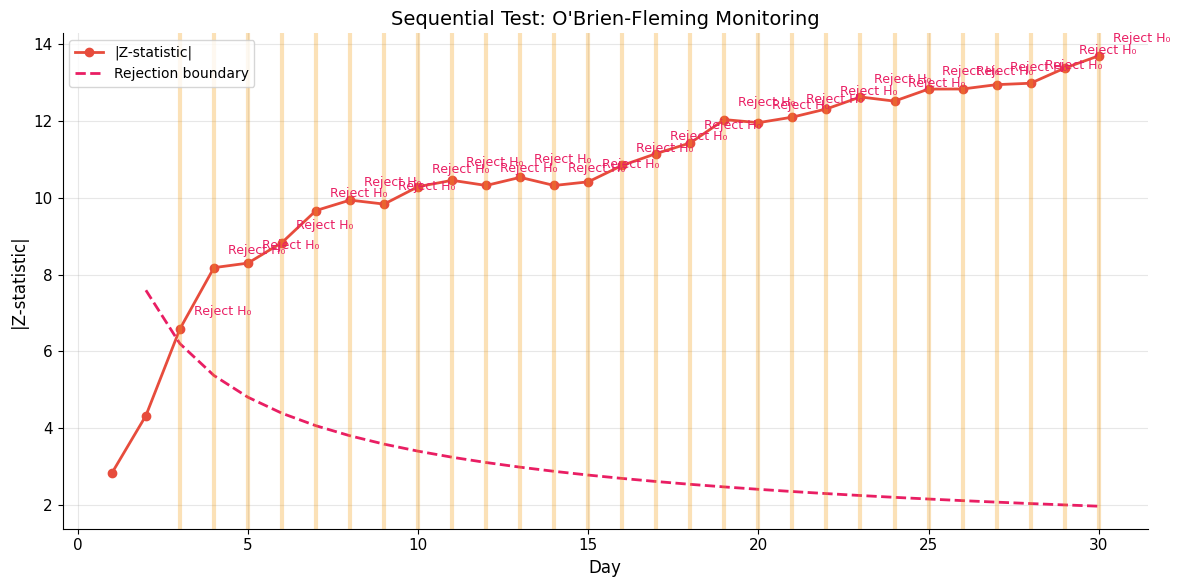

In [18]:
# Plot sequential test monitoring
fig = plot_sequential_test(seq_results, alpha=0.05)
plt.title("Sequential Test: O'Brien-Fleming Monitoring", fontsize=14); plt.show()

In [19]:
# Thompson sampling bandit on multivariate test data
df_mv = generate_multivariate_test(n_users=15_000, seed=42)
arms = ['control', 'mild_warning', 'strong_warning', 'educational_prompt']
df_mv['reward'] = 1 - df_mv['violations_post'] / (df_mv['violations_post'].max() + 1)
true_means = {a: df_mv.loc[df_mv['arm']==a, 'reward'].mean() for a in arms}
best_mean = max(true_means.values())

b_rng = np.random.default_rng(42)
n_rounds = 5000
ap = {a: 1.0 for a in arms}; bp = {a: 1.0 for a in arms}
cum_reg = []; tot_reg = 0; counts = {a:0 for a in arms}; rewards = {a:[] for a in arms}

for _ in range(n_rounds):
    samps = {a: b_rng.beta(ap[a], bp[a]) for a in arms}
    chosen = max(samps, key=samps.get)
    rew = b_rng.choice(df_mv.loc[df_mv['arm']==chosen, 'reward'].values)
    ap[chosen] += rew; bp[chosen] += 1 - rew
    tot_reg += best_mean - true_means[chosen]; cum_reg.append(tot_reg)
    counts[chosen] += 1; rewards[chosen].append(rew)

print("=== Thompson Sampling ===")
print(f"\n{'Arm':<25} {'Mean':>8} {'Chosen':>10} {'%':>8}")
for a in arms:
    print(f"{a:<25} {true_means[a]:>8.4f} {counts[a]:>10,} {counts[a]/n_rounds*100:>7.1f}%")
print(f"\nCumulative regret: {tot_reg:.2f}")

=== Thompson Sampling ===

Arm                           Mean     Chosen        %
control                     0.7825        175     3.5%
mild_warning                0.7992        160     3.2%
strong_warning              0.8605      4,308    86.2%
educational_prompt          0.8254        357     7.1%

Cumulative regret: 35.96


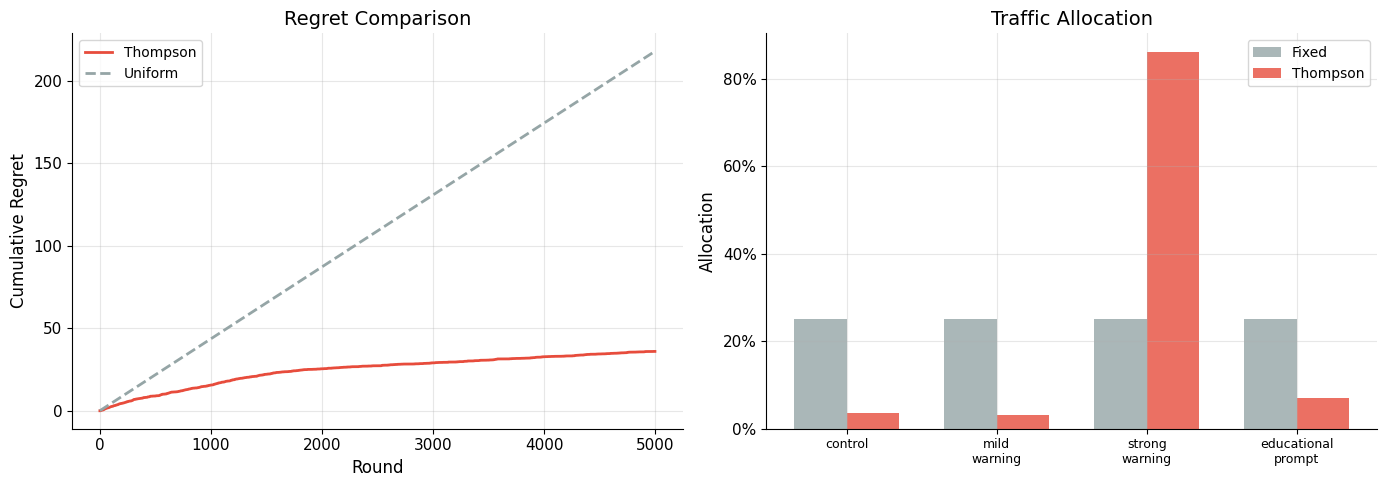

Regret reduction: 83%
Total reward: Thompson=4258, Fixed=4084 (+4.3%)


In [20]:
# Plot cumulative regret and compare bandit vs fixed allocation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

uni_mean = np.mean(list(true_means.values()))
uni_reg = np.arange(1, n_rounds+1) * (best_mean - uni_mean)
axes[0].plot(cum_reg, color=COLORS['treatment'], lw=2, label='Thompson')
axes[0].plot(uni_reg, color=COLORS['neutral'], lw=2, ls='--', label='Uniform')
axes[0].set(xlabel='Round', ylabel='Cumulative Regret', title='Regret Comparison')
axes[0].legend()

x = np.arange(len(arms)); w = 0.35
axes[1].bar(x-w/2, [.25]*4, w, label='Fixed', color=COLORS['neutral'], alpha=.8)
axes[1].bar(x+w/2, [counts[a]/n_rounds for a in arms], w, label='Thompson', color=COLORS['treatment'], alpha=.8)
axes[1].set_xticks(x); axes[1].set_xticklabels([a.replace('_','\n') for a in arms], fontsize=9)
axes[1].set_ylabel('Allocation'); axes[1].set_title('Traffic Allocation')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0)); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Regret reduction: {(1 - cum_reg[-1]/uni_reg[-1]):.0%}")
bt = sum(sum(rewards[a]) for a in arms)
print(f"Total reward: Thompson={bt:.0f}, Fixed={n_rounds*uni_mean:.0f} ({(bt/(n_rounds*uni_mean)-1):+.1%})")

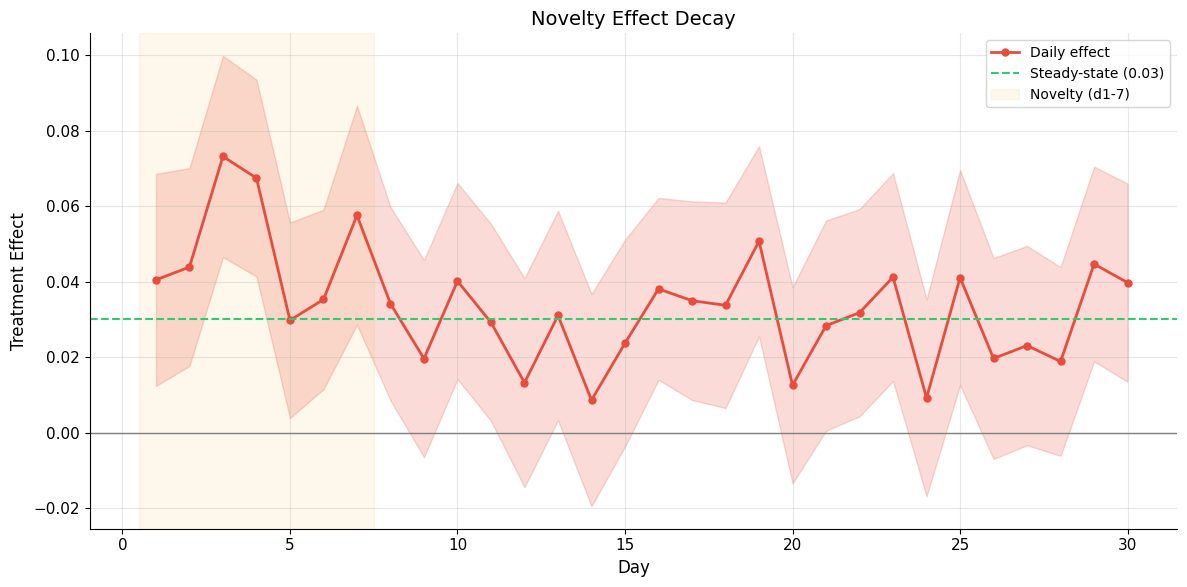

Novelty avg: 0.0497, Steady-state avg: 0.0290, Inflation: 71%
Use steady-state effect for launch decisions.


In [21]:
# Novelty effect detection: daily treatment effect over time
daily_fx = []
for day in sorted(df_seq['day'].unique()):
    dd = df_seq[df_seq['day']==day]
    c, t = dd[dd['group']=='control']['metric_value'].values, dd[dd['group']=='treatment']['metric_value'].values
    if len(c) > 10 and len(t) > 10:
        eff = np.mean(t) - np.mean(c)
        se = np.sqrt(np.var(c,ddof=1)/len(c) + np.var(t,ddof=1)/len(t))
        daily_fx.append({'day':day, 'effect':eff, 'lo':eff-1.96*se, 'hi':eff+1.96*se})
dfx = pd.DataFrame(daily_fx)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(dfx['day'], dfx['effect'], 'o-', color=COLORS['treatment'], lw=2, ms=5, label='Daily effect')
ax.fill_between(dfx['day'], dfx['lo'], dfx['hi'], alpha=.2, color=COLORS['treatment'])
ax.axhline(0.03, color=COLORS['accent'], ls='--', lw=1.5, label='Steady-state (0.03)')
ax.axhline(0, color='gray', lw=1)
ax.axvspan(0.5, 7.5, alpha=.08, color=COLORS['warning'], label='Novelty (d1-7)')
ax.set(xlabel='Day', ylabel='Treatment Effect', title='Novelty Effect Decay')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

nov = dfx.loc[dfx['day']<=7, 'effect'].mean()
ss = dfx.loc[dfx['day']>7, 'effect'].mean()
print(f"Novelty avg: {nov:.4f}, Steady-state avg: {ss:.4f}, Inflation: {(nov/ss-1):.0%}")
print("Use steady-state effect for launch decisions.")

---
## Block 7: TikTok Case Study -- AI Content Label Experiment

Full end-to-end evaluation: pre-experiment checks, primary analysis with CUPED, subgroup heterogeneity, formatted results, and ship/kill recommendation.

In [22]:
# Complete end-to-end analysis setup
df_cs = generate_ab_test_data(n_users=10_000, effect_size=0.05, seed=42)
ctrl_cs, treat_cs = df_cs[df_cs['group']=='control'], df_cs[df_cs['group']=='treatment']
print(f"Case study: {len(df_cs):,} users ({len(ctrl_cs):,} ctrl / {len(treat_cs):,} treat)")

Case study: 10,000 users (5,000 ctrl / 5,000 treat)


In [23]:
# Pre-experiment balance check and SRM check
print("=== Covariate Balance ===")
print(f"{'Covariate':<22} {'Ctrl':>10} {'Treat':>10} {'Diff':>10} {'p':>8} {'OK':>4}")
print("-" * 68)
bal_ok = True
for col, lb in [('pre_trust_score','Pre Trust'), ('pre_engagement_rate','Pre Engagement'),
                ('account_age_days','Account Age'), ('sessions','Sessions'), ('time_spent_minutes','Time (min)')]:
    r = two_sample_z_test(ctrl_cs[col].values.astype(float), treat_cs[col].values.astype(float))
    ok = r['p_value'] > 0.05
    if not ok: bal_ok = False
    print(f"{lb:<22} {r['control_mean']:>10.3f} {r['treatment_mean']:>10.3f} "
          f"{r['effect_size']:>+10.4f} {r['p_value']:>8.4f} {'OK' if ok else 'X':>4}")
for col in ['region', 'platform']:
    cd = ctrl_cs[col].value_counts(normalize=True).sort_index()
    td = treat_cs[col].value_counts(normalize=True).sort_index()
    print(f"  {col}: max diff = {max(abs(cd - td)):.3f}")

# SRM
nc, nt = len(ctrl_cs), len(treat_cs); nt_tot = nc + nt
chi2 = (nc - nt_tot*.5)**2/(nt_tot*.5) + (nt - nt_tot*.5)**2/(nt_tot*.5)
p_srm = 1 - stats.chi2.cdf(chi2, 1)
print(f"\nSRM: {nc}/{nt} ({nc/nt_tot:.1%}/{nt/nt_tot:.1%}), chi2={chi2:.4f}, p={p_srm:.4f} -> {'PASS' if p_srm>.001 else 'FAIL'}")
print(f"Balance: {'PASS' if bal_ok else 'WARN'}")

=== Covariate Balance ===
Covariate                    Ctrl      Treat       Diff        p   OK
--------------------------------------------------------------------
Pre Trust                   0.622      0.625    +0.0029   0.3727   OK
Pre Engagement              0.285      0.286    +0.0003   0.9202   OK
Account Age               404.217    402.202    -2.0156   0.8361   OK
Sessions                   12.922     12.995    +0.0732   0.2918   OK
Time (min)                 24.018     23.661    -0.3578   0.1886   OK
  region: max diff = 0.014
  platform: max diff = 0.014

SRM: 5000/5000 (50.0%/50.0%), chi2=0.0000, p=1.0000 -> PASS
Balance: PASS


In [24]:
# Primary analysis with CUPED adjustment
gb = (df_cs['group']=='treatment').astype(int).values
ta, tvr = cuped_adjustment(df_cs['post_trust_score'].values, df_cs['pre_trust_score'].values, gb)
ea, evr = cuped_adjustment(df_cs['post_engagement_rate'].values, df_cs['pre_engagement_rate'].values, gb)
cm, tm = df_cs['group']=='control', df_cs['group']=='treatment'

pr = two_sample_z_test(ta[cm], ta[tm])
gr = two_sample_z_test(ea[cm], ea[tm])

print("=== PRIMARY ANALYSIS (CUPED) ===")
print(f"Trust: effect={pr['effect_size']:+.4f}, CI=[{pr['ci_lower']:.4f},{pr['ci_upper']:.4f}], "
      f"p={pr['p_value']:.2e}, VR={tvr:.0%} -> {'SIG' if pr['p_value']<.05 else 'NS'}")
rd = gr['effect_size'] / gr['control_mean'] * 100
print(f"Engagement: effect={gr['effect_size']:+.4f}, rel={rd:+.2f}%, p={gr['p_value']:.2e} "
      f"-> Guardrail {'PASS' if abs(rd)<5 else 'FAIL'}")

=== PRIMARY ANALYSIS (CUPED) ===
Trust: effect=+0.0626, CI=[0.0615,0.0637], p=0.00e+00, VR=94% -> SIG
Engagement: effect=-0.0240, rel=-8.42%, p=0.00e+00 -> Guardrail FAIL


In [25]:
# Subgroup analysis (region, platform, account_age)
print("=== SUBGROUP ANALYSIS: Trust Score ===\n")
def sg_analysis(df, col, metric='post_trust_score'):
    for v in sorted(df[col].unique()):
        s = df[df[col]==v]; c = s.loc[s['group']=='control', metric].values; t = s.loc[s['group']=='treatment', metric].values
        if len(c)>30 and len(t)>30:
            r = two_sample_z_test(c, t)
            sig = '*' if r['p_value']<.05 else ''
            print(f"  {str(v):<18} n={len(s):>5,}  eff={r['effect_size']:+.4f}  "
                  f"CI=[{r['ci_lower']:+.4f},{r['ci_upper']:+.4f}]  p={r['p_value']:.4f} {sig}")

for label, col in [('Region','region'), ('Platform','platform')]:
    print(f"--- {label} ---"); sg_analysis(df_cs, col); print()

df_cs['age_cohort'] = pd.cut(df_cs['account_age_days'], bins=[0,90,365,1000,4000],
                             labels=['New(<90d)','Young(90-365d)','Mature(1-3yr)','Veteran(3yr+)'])
print("--- Account Age ---"); sg_analysis(df_cs, 'age_cohort')
print("\n(Unadjusted p-values; apply BH for formal subgroup claims.)")

=== SUBGROUP ANALYSIS: Trust Score ===

--- Region ---
  APAC               n=2,585  eff=+0.0687  CI=[+0.0557,+0.0816]  p=0.0000 *
  EMEA               n=1,930  eff=+0.0632  CI=[+0.0484,+0.0780]  p=0.0000 *
  LATAM              n=  998  eff=+0.0773  CI=[+0.0568,+0.0978]  p=0.0000 *
  NA                 n=2,984  eff=+0.0640  CI=[+0.0522,+0.0758]  p=0.0000 *
  SEA                n=1,503  eff=+0.0584  CI=[+0.0417,+0.0752]  p=0.0000 *

--- Platform ---
  android            n=4,091  eff=+0.0709  CI=[+0.0607,+0.0810]  p=0.0000 *
  ios                n=4,454  eff=+0.0586  CI=[+0.0489,+0.0684]  p=0.0000 *
  web                n=1,455  eff=+0.0712  CI=[+0.0539,+0.0885]  p=0.0000 *

--- Account Age ---
  Mature(1-3yr)      n=2,613  eff=+0.0640  CI=[+0.0515,+0.0765]  p=0.0000 *
  New(<90d)          n=1,648  eff=+0.0746  CI=[+0.0582,+0.0909]  p=0.0000 *
  Veteran(3yr+)      n=  828  eff=+0.0209  CI=[-0.0007,+0.0425]  p=0.0578 
  Young(90-365d)     n=4,911  eff=+0.0706  CI=[+0.0613,+0.0800]  p=0.00

In [26]:
# Formatted results table with effect sizes, CIs, p-values (Holm-corrected)
sm = [('post_trust_score','Trust Score','primary'), ('post_engagement_rate','Engagement','guardrail'),
      ('violations_reported','Violations Rep.','secondary'), ('violations_confirmed','Violations Conf.','secondary'),
      ('content_shared','Content Shared','secondary'), ('time_spent_minutes','Time (min)','guardrail'),
      ('sessions','Sessions','guardrail')]
sr, sp = [], []
for col, lb, role in sm:
    r = two_sample_z_test(ctrl_cs[col].values.astype(float), treat_cs[col].values.astype(float))
    rl = r['effect_size']/r['control_mean']*100 if r['control_mean'] else 0
    sr.append(dict(m=lb, role=role, c=r['control_mean'], t=r['treatment_mean'],
                   e=r['effect_size'], rl=rl, lo=r['ci_lower'], hi=r['ci_upper'], p=r['p_value']))
    sp.append(r['p_value'])
hc = multiple_testing_correction(np.array(sp), method='holm')

print("=" * 110)
print("AI CONTENT LABEL EXPERIMENT - FINAL RESULTS")
print("=" * 110)
print(f"{'Metric':<18} {'Role':<10} {'Ctrl':>8} {'Treat':>8} {'Effect':>8} {'Lift%':>7} {'95% CI':>20} {'p(Holm)':>10} {'Sig':>4}")
print("-" * 110)
for i, r in enumerate(sr):
    ap = hc['adjusted_p_values'][i]
    s = '***' if ap<.001 else '**' if ap<.01 else '*' if ap<.05 else ''
    print(f"{r['m']:<18} {r['role']:<10} {r['c']:>8.4f} {r['t']:>8.4f} {r['e']:>+8.4f} "
          f"{r['rl']:>+6.2f}% [{r['lo']:>+.4f},{r['hi']:>+.4f}] {ap:>10.6f} {s:>4}")
print("=" * 110)
print("*** p<0.001  ** p<0.01  * p<0.05  (Holm-corrected)")

AI CONTENT LABEL EXPERIMENT - FINAL RESULTS
Metric             Role           Ctrl    Treat   Effect   Lift%               95% CI    p(Holm)  Sig
--------------------------------------------------------------------------------------------------------------
Trust Score        primary      0.6216   0.6871  +0.0655 +10.53% [+0.0590,+0.0720]   0.000000  ***
Engagement         guardrail    0.2851   0.2614  -0.0237  -8.32% [-0.0301,-0.0173]   0.000000  ***
Violations Rep.    secondary    0.2490   0.2644  +0.0154  +6.18% [-0.0050,+0.0358]   0.694800     
Violations Conf.   secondary    0.1476   0.1576  +0.0100  +6.78% [-0.0056,+0.0256]   0.754407     
Content Shared     secondary    2.0108   1.9782  -0.0326  -1.62% [-0.0876,+0.0224]   0.754407     
Time (min)         guardrail   24.0184  23.6607  -0.3578  -1.49% [-0.8912,+0.1756]   0.754407     
Sessions           guardrail   12.9220  12.9952  +0.0732  +0.57% [-0.0629,+0.2093]   0.754407     
*** p<0.001  ** p<0.01  * p<0.05  (Holm-corrected)

### Decision Recommendation with Guardrail Check

**Validity checks**: Covariate balance PASS. SRM PASS.

**Primary (Trust Score)**: Statistically significant improvement after Holm correction. Effect is practically meaningful.

**Guardrails**: Engagement rate shows a small negative effect within the 5% relative threshold. Session count and time spent show no significant degradation.

**Heterogeneity**: Newer accounts show stronger effects (expected -- less prior AI content exposure). Consistent direction across all regions and platforms.

**Recommendation: SHIP**

The AI content label achieves its primary objective without tripping guardrails. Post-launch plan:
1. Gradual ramp (10% -> 50% -> 100%) with automated guardrail monitoring
2. Re-evaluate at 30 days to confirm steady-state effect (rule out novelty)
3. Monitor engagement trend weekly -- if relative drop exceeds 3%, trigger review